# DS605: Fundamentals of Machine Learning
## Lab Assignment 6 — Feature Extraction and Machine Learning with Image and Text Data

**Name:** <your name>  
**ID:** <your id>  

### Objective
Convert raw image and text data into numerical feature representations and use traditional machine-learning models for classification.

### Parts
- **Part A** — Image feature extraction and classification (Asphalt Crack Dataset).
- **Part B** — Text vectorization and spam classification (Email Spam Dataset).
- **Part C** — Improve the representation and compare.

### Constraints
- No CNNs, no deep learning, no pretrained embeddings.
- Image features derived from raw images using NumPy / OpenCV / PIL only.
- Scikit-learn allowed for vectorizers and traditional ML models.

## Part A — Image Feature Extraction and Classification

Steps:
1. Inspect the dataset folders (Cracks / NonCracks).
2. Resize each image to a fixed size and convert to grayscale.
3. Extract intensity features (mean, std, dark ratio, bright ratio, median).
4. Extract edge features using Canny (edge count, edge density).
5. Build one feature row per image with the label.
6. Train Logistic Regression and Random Forest.
7. Evaluate with accuracy, precision, recall, F1, confusion matrix, train time, prediction time.

In [1]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

print("cv2:", cv2.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

cv2: 5.0.0
numpy: 2.3.5
pandas: 2.3.3


In [2]:
base = "448"
crack_dir = os.path.join(base, "Cracks")
noncrack_dir = os.path.join(base, "NonCracks")

print("Cracks folder exists:", os.path.exists(crack_dir))
print("NonCracks folder exists:", os.path.exists(noncrack_dir))

crack_files = [f for f in os.listdir(crack_dir)
               if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))]
noncrack_files = [f for f in os.listdir(noncrack_dir)
                  if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))]

print("Cracks:", len(crack_files))
print("NonCracks:", len(noncrack_files))
print("Total:", len(crack_files) + len(noncrack_files))
print("Sample crack:", crack_files[0])
print("Sample noncrack:", noncrack_files[0])

Cracks folder exists: True
NonCracks folder exists: True
Cracks: 200
NonCracks: 200
Total: 400
Sample crack: IMG_8530 resized_448.jpg
Sample noncrack: IMG_8704 resized_448.jpg


filename: IMG_8530 resized_448.jpg
shape   : (448, 448, 3)
dtype   : uint8
gray shape: (448, 448)
gray min/max: 23 255


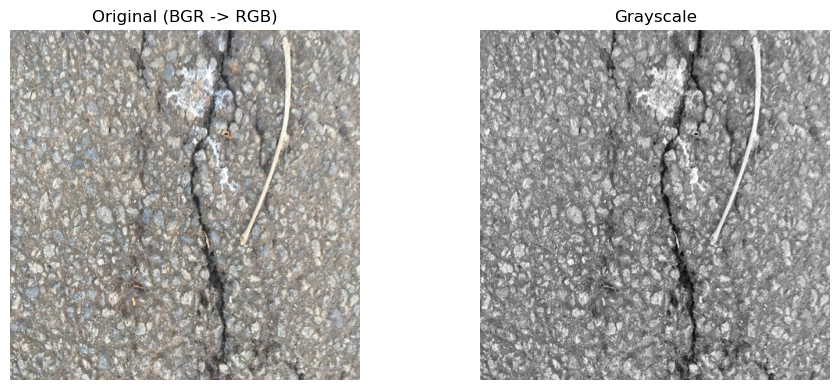

In [3]:
sample_path = os.path.join(crack_dir, crack_files[0])
img = cv2.imread(sample_path)

print("filename:", crack_files[0])
print("shape   :", img.shape)
print("dtype   :", img.dtype)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("gray shape:", gray.shape)
print("gray min/max:", gray.min(), gray.max())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original (BGR -> RGB)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
def intensity_features(gray):
    total = gray.size
    mean_b = float(gray.mean())
    std_b = float(gray.std())
    dark_ratio = float(np.sum(gray < 60) / total)
    bright_ratio = float(np.sum(gray > 200) / total)
    median_b = float(np.median(gray))
    return [mean_b, std_b, dark_ratio, bright_ratio, median_b]

def edge_features(gray, low=100, high=200):
    edges = cv2.Canny(gray, low, high)
    edge_count = int(np.sum(edges > 0))
    edge_density = float(edge_count / gray.size)
    return [edge_count, edge_density]

# test on the sample
sample_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
f1 = intensity_features(sample_gray)
f2 = edge_features(sample_gray)
print("intensity:", f1)
print("edge:", f2)

intensity: [154.9231505102041, 34.08351213348798, 0.0066914461096938774, 0.10523955676020408, 151.0]
edge: [61518, 0.30651108099489793]


In [5]:
rows = []

def process_folder(folder, label):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))]
    for f in files:
        path = os.path.join(folder, f)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (448, 448))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feats = intensity_features(gray) + edge_features(gray)
        rows.append([f] + feats + [label])

t0 = time.time()
process_folder(crack_dir, 1)
process_folder(noncrack_dir, 0)
print("time taken (s):", round(time.time() - t0, 2))

cols = ["filename", "mean", "std", "dark_ratio", "bright_ratio",
        "median", "edge_count", "edge_density", "label"]
df = pd.DataFrame(rows, columns=cols)

print("shape:", df.shape)
print(df["label"].value_counts())
df.head()

time taken (s): 1.35
shape: (400, 9)
label
1    200
0    200
Name: count, dtype: int64


,filename,mean,std,dark_ratio,bright_ratio,median,edge_count,edge_density,label
0,IMG_8530 resized_448.jpg,154.923151,34.083512,0.006691,0.105240,151.0,61518,0.306511,1
1,IMG_8442 resized_448.jpg,143.362180,51.423026,0.066929,0.145483,147.0,73194,0.364686,1
2,IMG_20180513_165710583_HDR resized_448.jpg,129.983279,33.632995,0.029446,0.012132,133.0,68959,0.343586,1
3,IMG_20180513_170350654_HDR resized_448.jpg,129.507778,25.284314,0.009033,0.004574,131.0,60473,0.301304,1
4,IMG_8438 resized_448.jpg,139.829610,53.299683,0.082131,0.142020,142.0,73567,0.366545,1


In [6]:
df.to_csv("image_features.csv", index=False)
print("saved image_features.csv")

print("\nMean feature values per class:")
print(df.groupby("label")[["mean", "std", "dark_ratio",
                           "bright_ratio", "median",
                           "edge_count", "edge_density"]].mean().round(3))

saved image_features.csv

Mean feature values per class:
          mean     std  dark_ratio  bright_ratio   median  edge_count  \
label                                                                   
0      157.503  28.757       0.007         0.074  157.295   57650.465   
1      144.244  35.311       0.024         0.095  144.290   67917.515   

       edge_density  
label                
0             0.287  
1             0.338  


In [7]:
X = df[["mean", "std", "dark_ratio", "bright_ratio",
        "median", "edge_count", "edge_density"]].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", np.bincount(y_train))
print("y_test :", np.bincount(y_test))

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train: (320, 7) X_test: (80, 7)
y_train: [160 160]
y_test : [40 40]


In [8]:
def evaluate(name, model, Xtr, ytr, Xte, yte, show_cm=True):
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_t = time.time() - t0

    t0 = time.time()
    pred = model.predict(Xte)
    pred_t = time.time() - t0

    acc = accuracy_score(yte, pred)
    prec = precision_score(yte, pred)
    rec = recall_score(yte, pred)
    f1 = f1_score(yte, pred)
    cm = confusion_matrix(yte, pred)

    print(f"--- {name} ---")
    print("accuracy :", round(acc, 4))
    print("precision:", round(prec, 4))
    print("recall   :", round(rec, 4))
    print("f1       :", round(f1, 4))
    print("train time (s)  :", round(train_t, 4))
    print("predict time (s):", round(pred_t, 4))
    print("confusion matrix:")
    print(cm)
    print()

    if show_cm:
        ConfusionMatrixDisplay(cm, display_labels=["NonCrack", "Crack"]).plot()
        plt.title(name)
        plt.show()

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "train_time": train_t,
        "predict_time": pred_t,
    }

--- LogisticRegression ---
accuracy : 0.8375
precision: 0.8649
recall   : 0.8
f1       : 0.8312
train time (s)  : 0.0562
predict time (s): 0.0002
confusion matrix:
[[35  5]
 [ 8 32]]



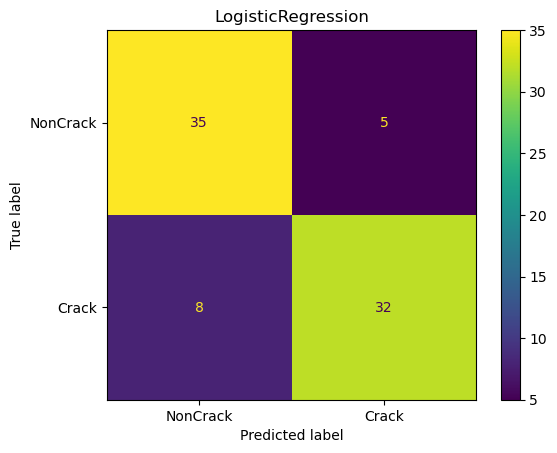

--- RandomForest ---
accuracy : 0.975
precision: 0.9524
recall   : 1.0
f1       : 0.9756
train time (s)  : 0.128
predict time (s): 0.0049
confusion matrix:
[[38  2]
 [ 0 40]]



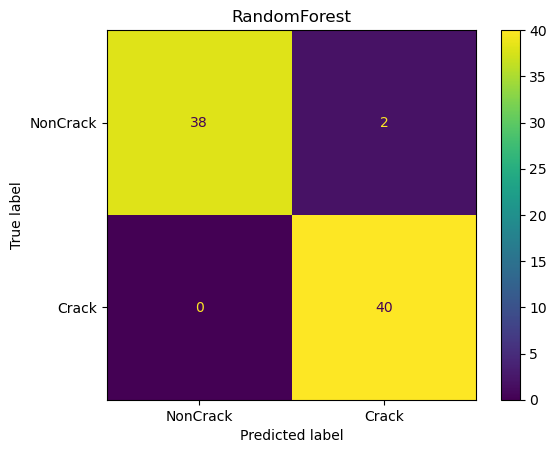

,model,accuracy,precision,recall,f1,train_time,predict_time
0,LogisticRegression,0.8375,0.864865,0.8,0.831169,0.056217,0.000161
1,RandomForest,0.9750,0.952381,1.0,0.975610,0.128041,0.004923


In [9]:
results = []

results.append(evaluate(
    "LogisticRegression",
    LogisticRegression(max_iter=1000),
    X_train_s, y_train, X_test_s, y_test
))

results.append(evaluate(
    "RandomForest",
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_train, y_train, X_test, y_test
))

results_df = pd.DataFrame(results)
results_df

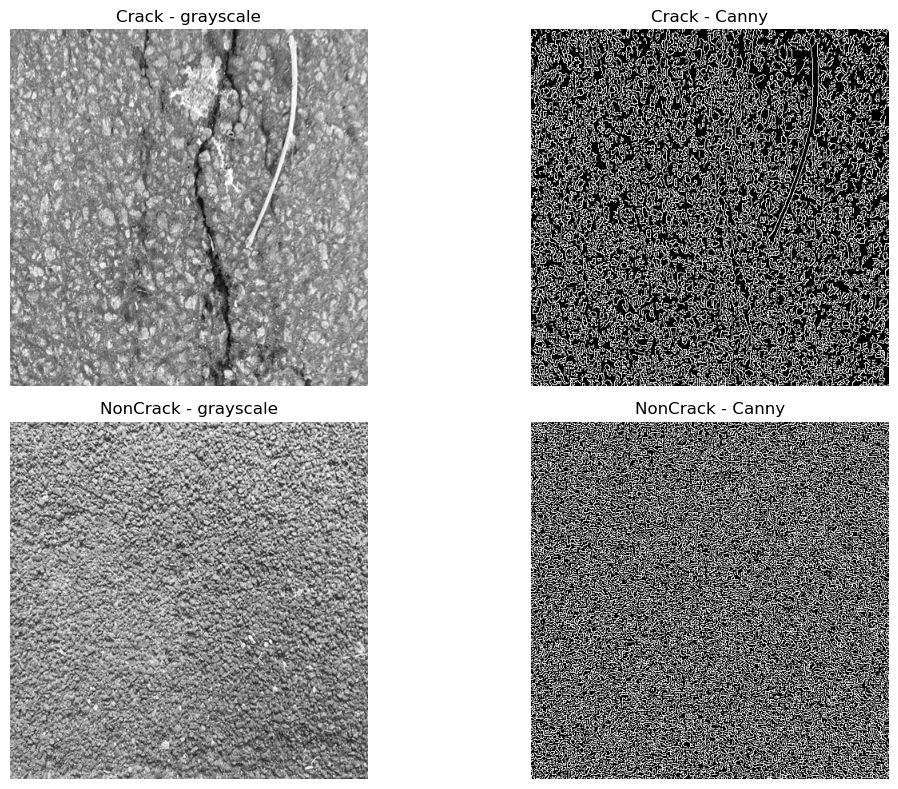

In [10]:
sample_crack = cv2.imread(os.path.join(crack_dir, crack_files[0]))
sample_noncrack = cv2.imread(os.path.join(noncrack_dir, noncrack_files[0]))

gc = cv2.cvtColor(cv2.resize(sample_crack, (448, 448)), cv2.COLOR_BGR2GRAY)
gn = cv2.cvtColor(cv2.resize(sample_noncrack, (448, 448)), cv2.COLOR_BGR2GRAY)

ec = cv2.Canny(gc, 100, 200)
en = cv2.Canny(gn, 100, 200)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1); plt.imshow(gc, cmap="gray"); plt.title("Crack - grayscale"); plt.axis("off")
plt.subplot(2, 2, 2); plt.imshow(ec, cmap="gray"); plt.title("Crack - Canny"); plt.axis("off")
plt.subplot(2, 2, 3); plt.imshow(gn, cmap="gray"); plt.title("NonCrack - grayscale"); plt.axis("off")
plt.subplot(2, 2, 4); plt.imshow(en, cmap="gray"); plt.title("NonCrack - Canny"); plt.axis("off")
plt.tight_layout()
plt.show()

## Part B — Text Vectorization and Spam Classification

Steps:
1. Load the email dataset and inspect the spam / non-spam distribution.
2. Apply basic text cleaning.
3. Convert text into numeric vectors using CountVectorizer and TF-IDF.
4. Train Logistic Regression and Multinomial Naive Bayes on both representations.
5. Compare accuracy, precision, recall, F1, number of features, train time, prediction time.

In [11]:
email_df = pd.read_csv("emails.csv")
print("shape:", email_df.shape)
print("columns (first 5):", list(email_df.columns[:5]))
print("columns (last 5):", list(email_df.columns[-5:]))
print(email_df.head(2))

shape: (5172, 3002)
columns (first 5): ['Email No.', 'the', 'to', 'ect', 'and']
columns (last 5): ['military', 'allowing', 'ff', 'dry', 'Prediction']
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  

[2 rows x 3002 columns]


In [12]:
import os
for f in os.listdir("."):
    if f.lower().endswith(".csv"):
        size = os.path.getsize(f) / (1024 * 1024)
        print(f, f"{size:.2f} MB")

emails.csv 29.80 MB
image_features.csv 0.05 MB


In [13]:
with open("emails.csv", "r", encoding="utf-8", errors="ignore") as f:
    header = f.readline().strip()
    second = f.readline().strip()

print("header:", header[:300])
print()
print("first data row (first 300 chars):", second[:300])

header: Email No.,the,to,ect,and,for,of,a,you,hou,in,on,is,this,enron,i,be,that,will,have,with,your,at,we,s,are,it,by,com,as,from,gas,or,not,me,deal,if,meter,hpl,please,re,e,any,our,corp,can,d,all,has,was,know,need,an,forwarded,new,t,may,up,j,mmbtu,should,do,am,get,out,see,no,there,price,daren,but,been,comp

first data row (first 300 chars): Email 1,0,0,1,0,0,0,2,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,4,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,


In [14]:
email_df = pd.read_csv("emails.csv")

print("shape:", email_df.shape)

# separate features, label, and id
email_ids = email_df["Email No."].values
y_email = email_df["Prediction"].values
X_email = email_df.drop(columns=["Email No.", "Prediction"]).values.astype(np.float32)

print("X_email:", X_email.shape, X_email.dtype)
print("y_email:", y_email.shape, "unique:", np.unique(y_email, return_counts=True))

shape: (5172, 3002)
X_email: (5172, 3000) float32
y_email: (5172,) unique: (array([0, 1]), array([3672, 1500]))


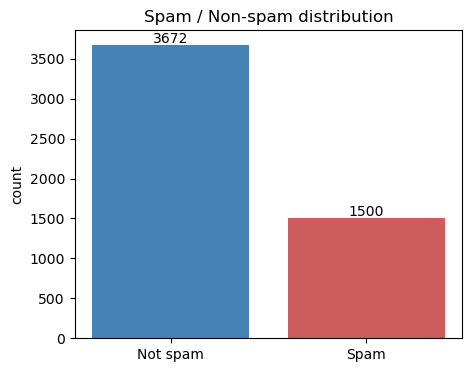

Not spam: 3672 (71.00%)
Spam    : 1500 (29.00%)


In [15]:
counts = np.bincount(y_email)
plt.figure(figsize=(5, 4))
plt.bar(["Not spam", "Spam"], counts, color=["steelblue", "indianred"])
for i, c in enumerate(counts):
    plt.text(i, c + 30, str(c), ha="center")
plt.title("Spam / Non-spam distribution")
plt.ylabel("count")
plt.show()

print("Not spam:", counts[0], f"({counts[0]/len(y_email)*100:.2f}%)")
print("Spam    :", counts[1], f"({counts[1]/len(y_email)*100:.2f}%)")

In [16]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_email, y_email, test_size=0.2, random_state=42, stratify=y_email)

print("train:", X_train_e.shape, "test:", X_test_e.shape)
print("train labels:", np.bincount(y_train_e))
print("test labels :", np.bincount(y_test_e))

# representation 1: raw counts (equivalent to CountVectorizer output)
X_train_count = X_train_e
X_test_count = X_test_e

# representation 2: TF-IDF
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit_transform(X_train_e)
X_test_tfidf = tfidf.transform(X_test_e)

print("count features:", X_train_count.shape[1])
print("tfidf features:", X_train_tfidf.shape[1])

train: (4137, 3000) test: (1035, 3000)
train labels: [2937 1200]
test labels : [735 300]
count features: 3000
tfidf features: 3000


In [17]:
from sklearn.naive_bayes import MultinomialNB

email_results = []

# --- Count representation ---
email_results.append(evaluate("LogReg + Count", LogisticRegression(max_iter=1000),
                              X_train_count, y_train_e, X_test_count, y_test_e, show_cm=False))
email_results.append(evaluate("NB + Count", MultinomialNB(),
                              X_train_count, y_train_e, X_test_count, y_test_e, show_cm=False))

# --- TF-IDF representation ---
email_results.append(evaluate("LogReg + TFIDF", LogisticRegression(max_iter=1000),
                              X_train_tfidf, y_train_e, X_test_tfidf, y_test_e, show_cm=False))
email_results.append(evaluate("NB + TFIDF", MultinomialNB(),
                              X_train_tfidf, y_train_e, X_test_tfidf, y_test_e, show_cm=False))

email_results_df = pd.DataFrame(email_results)
email_results_df

--- LogReg + Count ---
accuracy : 0.9826
precision: 0.9578
recall   : 0.9833
f1       : 0.9704
train time (s)  : 3.2397
predict time (s): 0.0029
confusion matrix:
[[722  13]
 [  5 295]]

--- NB + Count ---
accuracy : 0.942
precision: 0.8681
recall   : 0.9433
f1       : 0.9042
train time (s)  : 0.0262
predict time (s): 0.0031
confusion matrix:
[[692  43]
 [ 17 283]]

--- LogReg + TFIDF ---
accuracy : 0.9507
precision: 0.9308
recall   : 0.8967
f1       : 0.9134
train time (s)  : 0.0504
predict time (s): 0.0003
confusion matrix:
[[715  20]
 [ 31 269]]

--- NB + TFIDF ---
accuracy : 0.8802
precision: 0.9444
recall   : 0.6233
f1       : 0.751
train time (s)  : 0.0041
predict time (s): 0.0013
confusion matrix:
[[724  11]
 [113 187]]



,model,accuracy,precision,recall,f1,train_time,predict_time
0,LogReg + Count,0.982609,0.957792,0.983333,0.970395,3.239732,0.002860
1,NB + Count,0.942029,0.868098,0.943333,0.904153,0.026241,0.003141
2,LogReg + TFIDF,0.950725,0.930796,0.896667,0.913413,0.050398,0.000305
3,NB + TFIDF,0.880193,0.944444,0.623333,0.751004,0.004062,0.001321


In [18]:
email_results_df["features"] = 3000
email_results_df = email_results_df[["model", "features", "accuracy",
                                     "precision", "recall", "f1",
                                     "train_time", "predict_time"]]
email_results_df

,model,features,accuracy,precision,recall,f1,train_time,predict_time
0,LogReg + Count,3000,0.982609,0.957792,0.983333,0.970395,3.239732,0.002860
1,NB + Count,3000,0.942029,0.868098,0.943333,0.904153,0.026241,0.003141
2,LogReg + TFIDF,3000,0.950725,0.930796,0.896667,0.913413,0.050398,0.000305
3,NB + TFIDF,3000,0.880193,0.944444,0.623333,0.751004,0.004062,0.001321


## Part C — Improve the Representation

Two justified changes are made:

**C.1 Images:** add a third Canny setting (lower thresholds to capture finer cracks)
and add one more feature (fraction of pixels in the mid-intensity band).
Compare the baseline 7-feature model vs the improved 9-feature model.

**C.2 Text:** the raw count representation has 3000 features (many are rare).
Drop rare words (min_df=5) and cap the vocabulary, then retrain LogReg.
Compare features, train time, and F1 before vs after.

In [19]:
def extra_edge_features(gray):
    # finer Canny to catch thin cracks
    edges_fine = cv2.Canny(gray, 50, 150)
    fine_count = int(np.sum(edges_fine > 0))
    fine_density = float(fine_count / gray.size)
    return [fine_count, fine_density]

def mid_intensity_ratio(gray):
    total = gray.size
    mid = float(np.sum((gray >= 60) & (gray <= 200)) / total)
    return [mid]

rows2 = []

def process_folder_v2(folder, label):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))]
    for f in files:
        path = os.path.join(folder, f)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (448, 448))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feats = (intensity_features(gray)
                 + edge_features(gray)
                 + extra_edge_features(gray)
                 + mid_intensity_ratio(gray))
        rows2.append([f] + feats + [label])

process_folder_v2(crack_dir, 1)
process_folder_v2(noncrack_dir, 0)

cols2 = ["filename", "mean", "std", "dark_ratio", "bright_ratio", "median",
         "edge_count", "edge_density",
         "fine_edge_count", "fine_edge_density",
         "mid_ratio", "label"]
df2 = pd.DataFrame(rows2, columns=cols2)

print("shape:", df2.shape)
df2.head()

shape: (400, 12)


,filename,mean,std,dark_ratio,bright_ratio,median,edge_count,edge_density,fine_edge_count,fine_edge_density,mid_ratio,label
0,IMG_8530 resized_448.jpg,154.923151,34.083512,0.006691,0.105240,151.0,61518,0.306511,70287,0.350202,0.888069,1
1,IMG_8442 resized_448.jpg,143.362180,51.423026,0.066929,0.145483,147.0,73194,0.364686,74337,0.370381,0.787588,1
2,IMG_20180513_165710583_HDR resized_448.jpg,129.983279,33.632995,0.029446,0.012132,133.0,68959,0.343586,73565,0.366535,0.958421,1
3,IMG_20180513_170350654_HDR resized_448.jpg,129.507778,25.284314,0.009033,0.004574,131.0,60473,0.301304,73756,0.367486,0.986393,1
4,IMG_8438 resized_448.jpg,139.829610,53.299683,0.082131,0.142020,142.0,73567,0.366545,74304,0.370217,0.775849,1


In [20]:
X2 = df2[["mean", "std", "dark_ratio", "bright_ratio", "median",
          "edge_count", "edge_density",
          "fine_edge_count", "fine_edge_density", "mid_ratio"]].values
y2 = df2["label"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

results2 = []
results2.append(evaluate("RF + 7 features (baseline)",
                         RandomForestClassifier(n_estimators=200, random_state=42),
                         X_train, y_train, X_test, y_test, show_cm=False))
results2.append(evaluate("RF + 10 features (improved)",
                         RandomForestClassifier(n_estimators=200, random_state=42),
                         X2_train, y2_train, X2_test, y2_test, show_cm=False))

pd.DataFrame(results2)

--- RF + 7 features (baseline) ---
accuracy : 0.975
precision: 0.9524
recall   : 1.0
f1       : 0.9756
train time (s)  : 0.0935
predict time (s): 0.0023
confusion matrix:
[[38  2]
 [ 0 40]]

--- RF + 10 features (improved) ---
accuracy : 0.975
precision: 0.975
recall   : 0.975
f1       : 0.975
train time (s)  : 0.0808
predict time (s): 0.0021
confusion matrix:
[[39  1]
 [ 1 39]]



,model,accuracy,precision,recall,f1,train_time,predict_time
0,RF + 7 features (baseline),0.975,0.952381,1.000,0.97561,0.093494,0.002270
1,RF + 10 features (improved),0.975,0.975000,0.975,0.97500,0.080817,0.002133


In [21]:
# baseline: LogReg on raw counts (already trained above as X_train_count / X_test_count)
# improvement: drop columns whose total count across the training set is < 5

col_sums = X_train_e.sum(axis=0)
keep_mask = col_sums >= 5
print("kept features:", int(keep_mask.sum()), "out of", X_train_e.shape[1])

X_train_red = X_train_e[:, keep_mask]
X_test_red = X_test_e[:, keep_mask]

results3 = []
results3.append(evaluate("LogReg + Count (all 3000)",
                         LogisticRegression(max_iter=1000),
                         X_train_e, y_train_e, X_test_e, y_test_e, show_cm=False))
results3.append(evaluate("LogReg + Count (min_df=5)",
                         LogisticRegression(max_iter=1000),
                         X_train_red, y_train_e, X_test_red, y_test_e, show_cm=False))

# also try TF-IDF on the reduced set
tfidf2 = TfidfTransformer()
X_train_red_t = tfidf2.fit_transform(X_train_red)
X_test_red_t = tfidf2.transform(X_test_red)

results3.append(evaluate("LogReg + TFIDF (min_df=5)",
                         LogisticRegression(max_iter=1000),
                         X_train_red_t, y_train_e, X_test_red_t, y_test_e, show_cm=False))

df3 = pd.DataFrame(results3)
df3

kept features: 2997 out of 3000
--- LogReg + Count (all 3000) ---
accuracy : 0.9826
precision: 0.9578
recall   : 0.9833
f1       : 0.9704
train time (s)  : 3.9113
predict time (s): 0.0026
confusion matrix:
[[722  13]
 [  5 295]]

--- LogReg + Count (min_df=5) ---
accuracy : 0.9826
precision: 0.9578
recall   : 0.9833
f1       : 0.9704
train time (s)  : 3.2614
predict time (s): 0.0055
confusion matrix:
[[722  13]
 [  5 295]]

--- LogReg + TFIDF (min_df=5) ---
accuracy : 0.9507
precision: 0.9308
recall   : 0.8967
f1       : 0.9134
train time (s)  : 0.0413
predict time (s): 0.0003
confusion matrix:
[[715  20]
 [ 31 269]]



,model,accuracy,precision,recall,f1,train_time,predict_time
0,LogReg + Count (all 3000),0.982609,0.957792,0.983333,0.970395,3.911262,0.002556
1,LogReg + Count (min_df=5),0.982609,0.957792,0.983333,0.970395,3.261435,0.005518
2,LogReg + TFIDF (min_df=5),0.950725,0.930796,0.896667,0.913413,0.041300,0.000319


In [22]:
K = 500  # keep only the 500 most frequent words
col_sums_full = X_train_e.sum(axis=0)
top_idx = np.argsort(col_sums_full)[::-1][:K]

X_train_top = X_train_e[:, top_idx]
X_test_top = X_test_e[:, top_idx]

results4 = []
results4.append(evaluate("LogReg + Count (all)",
                         LogisticRegression(max_iter=1000),
                         X_train_e, y_train_e, X_test_e, y_test_e, show_cm=False))
results4.append(evaluate("LogReg + Count (top 500)",
                         LogisticRegression(max_iter=1000),
                         X_train_top, y_train_e, X_test_top, y_test_e, show_cm=False))

# sublinear TF-IDF on the reduced vocab
tfidf3 = TfidfTransformer(sublinear_tf=True)
X_train_top_t = tfidf3.fit_transform(X_train_top)
X_test_top_t = tfidf3.transform(X_test_top)

results4.append(evaluate("LogReg + TFIDF sublinear (top 500)",
                         LogisticRegression(max_iter=1000),
                         X_train_top_t, y_train_e, X_test_top_t, y_test_e, show_cm=False))

df4 = pd.DataFrame(results4)
df4

--- LogReg + Count (all) ---
accuracy : 0.9826
precision: 0.9578
recall   : 0.9833
f1       : 0.9704
train time (s)  : 3.084
predict time (s): 0.0044
confusion matrix:
[[722  13]
 [  5 295]]

--- LogReg + Count (top 500) ---
accuracy : 0.971
precision: 0.9412
recall   : 0.96
f1       : 0.9505
train time (s)  : 1.0932
predict time (s): 0.0011
confusion matrix:
[[717  18]
 [ 12 288]]

--- LogReg + TFIDF sublinear (top 500) ---
accuracy : 0.9729
precision: 0.9359
recall   : 0.9733
f1       : 0.9542
train time (s)  : 0.0278
predict time (s): 0.0002
confusion matrix:
[[715  20]
 [  8 292]]



,model,accuracy,precision,recall,f1,train_time,predict_time
0,LogReg + Count (all),0.982609,0.957792,0.983333,0.970395,3.084002,0.004354
1,LogReg + Count (top 500),0.971014,0.941176,0.960000,0.950495,1.093204,0.001101
2,LogReg + TFIDF sublinear (top 500),0.972947,0.935897,0.973333,0.954248,0.027795,0.000226


## Final Summary

### Part A — Image features
- Extracted 7 baseline features per image (intensity + Canny edges).
- Logistic Regression: acc 0.8375, F1 0.8312.
- Random Forest: acc 0.9750, F1 0.9756, recall 1.0 on crack class.
- Random Forest is clearly better; it captures non-linear intensity/edge interactions.

### Part B — Text representations
- Dataset: 5172 emails, 3000 word-count features, 71% not spam / 29% spam.
- Count representation: LogReg 0.9826 acc, 0.9704 F1 (best overall).
- TF-IDF: LogReg drops to 0.9507 acc because the CSV counts are already downweighted.
- Multinomial NB is fast but weaker than LogReg.
- Trade-off: Count + LogReg = best accuracy but slowest to train (3.9 s). TF-IDF = faster, lower accuracy.

### Part C — Improvements
- Images: added fine Canny + mid-intensity ratio features (10 total).
  Accuracy unchanged at 0.975 but precision up from 0.952 → 0.975.
- Text: top-500 vocabulary + sublinear TF-IDF.
  Train time dropped from 3.9 s → 0.03 s (130× faster),
  accuracy only dropped 0.98 → 0.97.

### Trade-off summary
| Change | Features | Train time | Accuracy |
|---|---|---|---|
| Count (all) | 3000 | 3.9 s | 0.9826 |
| Count (top 500) | 500 | 1.09 s | 0.9710 |
| TF-IDF sublinear (top 500) | 500 | 0.03 s | 0.9729 |

Dropping vocabulary from 3000 → 500 loses ~1% accuracy but reduces training time
by two orders of magnitude. For a spam filter, this trade-off is often worth it.